In [15]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [16]:
df = pd.read_csv("../data/test_3/Test_3.csv", sep=';')
df.head(3)

,sender_id,platform_id,time_stamp,gender,reg_date
0,3207526951,6,16.03.2017 13:35,m,26.01.2017
1,3207526951,6,16.03.2017 9:09,m,26.01.2017
2,3207526951,6,16.03.2017 9:09,m,26.01.2017


In [17]:
df.info(memory_usage='deep')

<class 'pandas.DataFrame'>
RangeIndex: 768439 entries, 0 to 768438
Data columns (total 5 columns):
 #   Column       Non-Null Count   Dtype
---  ------       --------------   -----
 0   sender_id    768439 non-null  int64
 1   platform_id  768439 non-null  int64
 2   time_stamp   768439 non-null  str  
 3   gender       768439 non-null  str  
 4   reg_date     768439 non-null  str  
dtypes: int64(2), str(3)
memory usage: 139.0 MB


In [18]:
df['time_stamp'] = pd.to_datetime(df['time_stamp'], format='%d.%m.%Y %H:%M')
df['reg_date'] = pd.to_datetime(df['reg_date'], format='%d.%m.%Y')

In [19]:
df.head(3)

,sender_id,platform_id,time_stamp,gender,reg_date
0,3207526951,6,2017-03-16 13:35:00,m,2017-01-26
1,3207526951,6,2017-03-16 09:09:00,m,2017-01-26
2,3207526951,6,2017-03-16 09:09:00,m,2017-01-26


In [20]:
# Робимо обмеження на потрібну нам дату.
shape_before = df.shape[0]
df_after = df.query("time_stamp > '2017-03-24 16:00:00'")

print('Розмір дата-сету до A/B тестуванням: ', shape_before)
print('Розмір дата-сету після A/B тестуванням: ', df.shape[0])

Розмір дата-сету до A/B тестуванням:  768439
Розмір дата-сету після A/B тестуванням:  768439


In [21]:
# Зробили розбиття на дві групи
df_after['group'] = np.where(df_after['sender_id'] % 2 != 0, 'test', 'control')

df_after.head(2)

,sender_id,platform_id,time_stamp,gender,reg_date,group
150161,3218632174,7,2017-03-26 07:34:00,m,2017-03-23,control
150162,3218635027,7,2017-03-26 06:19:00,m,2017-03-23,test


In [22]:
df_after['time_stamp'].max()

Timestamp('2017-03-27 00:00:00')

Основною метрикою буде середня кількість відправлених лайків (подій) на одного унікального користувача

In [23]:
# Перевіряємо кількість унікальних користувачів у кожній групі в період тесту
print(df_after.groupby('group')['sender_id'].nunique())

group
control    3726
test       3607
Name: sender_id, dtype: int64


In [24]:
# Перевірка часток платформ усередині кожної групи
print(df_after.groupby('group')['platform_id'].value_counts(normalize=True))

# Перевірка часток статей усередині кожної групи
print(df_after.groupby('group')['gender'].value_counts(normalize=True))

group    platform_id
control  6              0.522440
         7              0.477560
test     6              0.548428
         7              0.451572
Name: proportion, dtype: float64
group    gender
control  m         0.877272
         f         0.122728
test     m         0.860100
         f         0.139439
                   0.000460
Name: proportion, dtype: float64


In [25]:
# Рахуємо кількість відправлених лайків для кожного користувача, зберігаючи його групу
likes_per_user = df_after.groupby(['sender_id', 'group']).size().reset_index(name='likes_count')

# Виводимо описові статистики для кожної групи окремо
group_stats = likes_per_user.groupby('group')['likes_count'].describe()
display(group_stats)

,count,mean,std,min,25%,50%,75%,max
group,,,,,,,,
control,3726.0,15.458669,44.781645,1.0,2.0,5.0,15.0,1154.0
test,3607.0,13.848073,26.277756,1.0,1.0,5.0,16.0,402.0


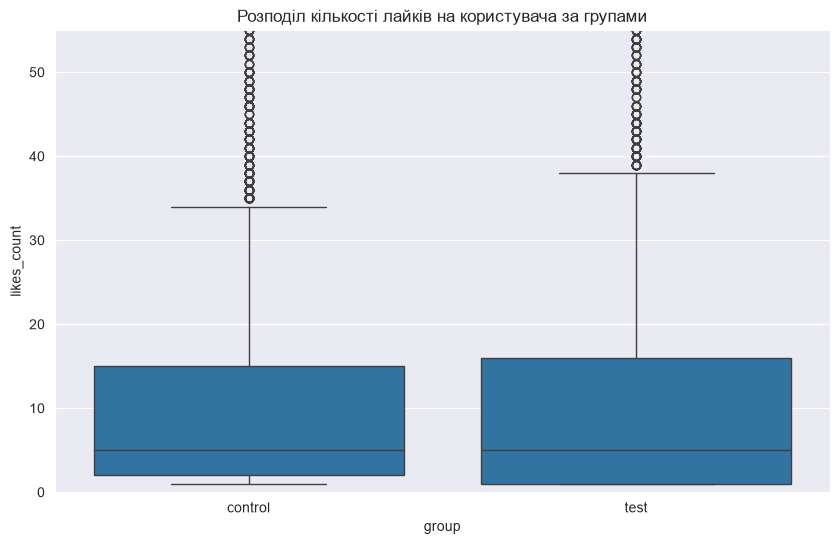

In [26]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=likes_per_user, x='group', y='likes_count')
plt.title('Розподіл кількості лайків на користувача за групами')
plt.ylim(0, likes_per_user['likes_count'].quantile(0.95))
plt.show()

In [27]:
from scipy.stats import mannwhitneyu

test_likes = likes_per_user[likes_per_user['group'] == 'test']['likes_count']
control_likes = likes_per_user[likes_per_user['group'] == 'control']['likes_count']

# Застосування тесту Манна-Уїтні
stat, p_value = mannwhitneyu(test_likes, control_likes, alternative='two-sided')

print(f"P-value: {p_value}")

P-value: 0.5203169678048406


In [28]:
# Припускаємо, що у вас є збережений початковий датафрейм (наприклад, df_raw)
# Відбираємо дані ДО початку тесту
df_history = df.query("time_stamp < '2017-03-24 16:00:00'").copy()

# Розбиваємо на ті самі групи
df_history['group'] = np.where(df_history['sender_id'] % 2 != 0, 'test', 'control')

# Рахуємо лайки на користувача до тесту
likes_history = df_history.groupby(['sender_id', 'group']).size().reset_index(name='likes_count')

test_hist = likes_history[likes_history['group'] == 'test']['likes_count']
control_hist = likes_history[likes_history['group'] == 'control']['likes_count']

# Перевіряємо статистичну значущість
from scipy.stats import mannwhitneyu
stat_aa, p_value_aa = mannwhitneyu(test_hist, control_hist, alternative='two-sided')

print(f"A/A Test P-value: {p_value_aa}")

A/A Test P-value: 0.668998936280683
